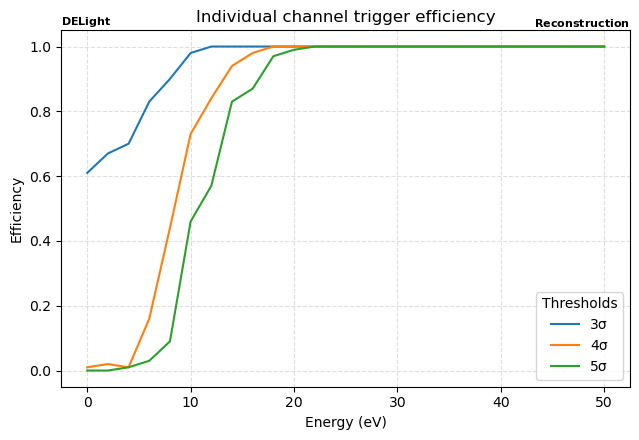


Pass rates:
Energy           3σ          4σ          5σ
0            0.6100     0.0100     0.0000
2            0.6700     0.0200     0.0000
4            0.7000     0.0100     0.0100
6            0.8300     0.1600     0.0300
8            0.9000     0.4400     0.0900
10           0.9800     0.7300     0.4600
12           1.0000     0.8400     0.5700
14           1.0000     0.9400     0.8300
16           1.0000     0.9800     0.8700
18           1.0000     1.0000     0.9700
20           1.0000     1.0000     0.9900
22           1.0000     1.0000     1.0000
24           1.0000     1.0000     1.0000
26           1.0000     1.0000     1.0000
28           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
32           1.0000     1.0000     1.0000
34           1.0000     1.0000     1.0000
36           1.0000     1.0000     1.0000
38           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
42           1.0000     1.0000     1.0000
44           1.0000

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
import re
from pathlib import Path

base_dir = Path("/ceph/dwong/trigger_samples/v2_300k/indiv_max_amp")

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Individual channel trigger efficiency")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")

# Add "shoulder" labels
ax = plt.gca()
# Left shoulder (bold)
ax.text(0.0, 1.005, r"$\mathbf{DELight}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
# Right shoulder (bold)
ax.text(1.0, 1.005, r"$\mathbf{Reconstruction}$",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


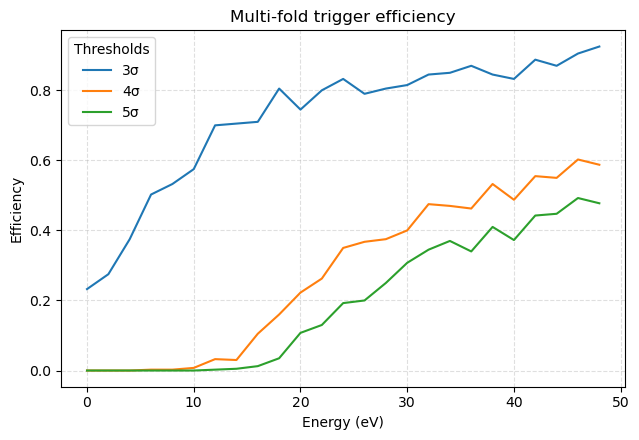


Pass rates (2nd-highest channel ≥ threshold):
Energy           3σ          4σ          5σ
0            0.2325     0.0000     0.0000
2            0.2750     0.0000     0.0000
4            0.3750     0.0000     0.0000
6            0.5025     0.0025     0.0000
8            0.5325     0.0025     0.0000
10           0.5750     0.0075     0.0000
12           0.7000     0.0325     0.0025
14           0.7050     0.0300     0.0050
16           0.7100     0.1050     0.0125
18           0.8050     0.1600     0.0350
20           0.7450     0.2225     0.1075
22           0.8000     0.2625     0.1300
24           0.8325     0.3500     0.1925
26           0.7900     0.3675     0.2000
28           0.8050     0.3750     0.2500
30           0.8150     0.4000     0.3075
32           0.8450     0.4750     0.3450
34           0.8500     0.4700     0.3700
36           0.8700     0.4625     0.3400
38           0.8450     0.5325     0.4100
40           0.8325     0.4875     0.3725
42           0.8875     0.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Settings ---
base_dir = Path("max_amp_400")
thresholds = [2.30, 3.07, 3.84]   # pass if 2nd-largest channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)

# --- Compute pass rates (using 2nd-largest across 56 channels) ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)

    # 2nd-largest value per repeat:
    # For small arrays (100x56), full sort is simple & clear.
    second_largest = np.sort(data, axis=1)[:, -2]  # shape (R,)

    for thr in thresholds:
        passes = second_largest >= thr
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency")
plt.title("Multi-fold trigger efficiency")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates (2nd-highest channel ≥ threshold):")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))
